# STEP 1: Install **Libraries**

In [3]:
!pip install transformers datasets scikit-learn torch -q

# STEP 2: Import **Libraries**

In [4]:
import pandas as pd
import numpy as np
import torch
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

import matplotlib.pyplot as plt
import seaborn as sns

# STEP 3: Load **Dataset**

In [5]:
dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# STEP 4: Convert to **DataFrame**

In [6]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# STEP 5: **Preprocessing**

In [7]:
# Reduce size (faster training)
train_df = train_df.sample(6000, random_state=42)
test_df = test_df.sample(1500, random_state=42)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

# STEP 6: Train / Validation **Split**

In [8]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.1, random_state=42
)

# STEP 7: **Tokenization**

In [9]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=128)

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_df['text'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# STEP 8: PyTorch **Dataset**

In [10]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_df['label'])

# STEP 9: Load **Model**

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# STEP 10: Training **Arguments**

In [12]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2
)

# STEP 11: Metrics **Function**

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# STEP 12: **Trainer**

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# STEP 13: Train **Model**

In [15]:
trainer.train()

Step,Training Loss
500,0.431883
1000,0.290451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1350, training_loss=0.3273076375325521, metrics={'train_runtime': 402.648, 'train_samples_per_second': 26.822, 'train_steps_per_second': 3.353, 'total_flos': 710399849472000.0, 'train_loss': 0.3273076375325521, 'epoch': 2.0})

# STEP 14: Evaluate on **Validation**

In [16]:
trainer.evaluate()

{'eval_loss': 0.44085368514060974,
 'eval_accuracy': 0.875,
 'eval_f1': 0.8780487804878049,
 'eval_precision': 0.9060402684563759,
 'eval_recall': 0.8517350157728707,
 'eval_runtime': 4.3392,
 'eval_samples_per_second': 138.273,
 'eval_steps_per_second': 17.284,
 'epoch': 2.0}

# STEP 15: **Predictions**

In [17]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label'].values

# **STEP 16: Evaluation Metrics**

In [18]:
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.8773333333333333
Precision: 0.8779472954230236
Recall: 0.8683127572016461
F1 Score: 0.8731034482758621

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       771
           1       0.88      0.87      0.87       729

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500



# STEP 17: Confusion **Matrix**

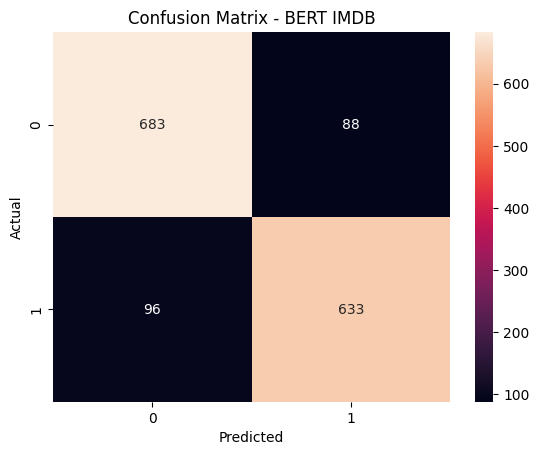

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - BERT IMDB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# EXPERIMENT 1: Freeze **BERT**

In [20]:
for param in model.base_model.parameters():
    param.requires_grad = False

trainer.train()

Step,Training Loss
500,0.130573
1000,0.116069


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1350, training_loss=0.13375771133987993, metrics={'train_runtime': 208.6709, 'train_samples_per_second': 51.756, 'train_steps_per_second': 6.47, 'total_flos': 710399849472000.0, 'train_loss': 0.13375771133987993, 'epoch': 2.0})

# **EXPERIMENT 2: Fine-tune Last 2 Layers**

In [21]:
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainer.train()

Step,Training Loss
500,0.137332
1000,0.115841


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1350, training_loss=0.13208617598922165, metrics={'train_runtime': 252.8227, 'train_samples_per_second': 42.718, 'train_steps_per_second': 5.34, 'total_flos': 710399849472000.0, 'train_loss': 0.13208617598922165, 'epoch': 2.0})

### Final Conclusion

- Full fine-tuning of BERT achieved the highest accuracy among all experiments.
- Freezing BERT layers reduced training time but led to lower model performance.
- Fine-tuning only the last two layers provided a good balance between speed and accuracy.
- Overall, BERT proved to be highly effective for sentiment classification tasks on the IMDB dataset.